## **FINAL PROJECT PCD**

In [ ]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)

Kode diatas memuat berbagai pustaka (library) yang diperlukan untuk mendukung alur kerja pengembangan sistem pengenalan objek berbasis citra. Secara sistematis, kode tersebut mengimpor modul untuk pengelolaan data gambar, ekstraksi fitur statistik dari citra, serta penerapan berbagai algoritma klasifikasi seperti Random Forest, SVM, dan K-Nearest Neighbors. Selain itu, disertakan pula pustaka untuk pengolahan data numerik, visualisasi hasil, serta perangkat evaluasi untuk mengukur kinerja model klasifikasi berdasarkan parameter seperti akurasi dan confusion matrix.

In [ ]:
data = []
labels = []
file_name = []

dataset_path = "dataset/"

for sub_folder in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, sub_folder)

    if not os.path.isdir(full_path):
        continue

    sub_folder_files = os.listdir(full_path)
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join(full_path, filename)
        img = cv.imread(img_path)
        if img is not None:
            img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
            img = cv.resize(img, (256, 256)) 
            img = img.astype(np.uint8)

            data.append(img)
            labels.append(sub_folder)
            name = os.path.splitext(filename)[0]
            file_name.append(filename)

data = np.array(data)
labels = np.array(labels)

Kode diatas berfungsi untuk proses pemuatan (loading) dan pra-pemrosesan dataset gambar secara otomatis dari direktori penyimpanan. Program melakukan iterasi melalui setiap sub-folder di dalam direktori dataset, membaca file gambar yang ditemukan, lalu mengubahnya menjadi format grayscale serta menyeragamkan ukuran gambar menjadi 256x256 piksel. Seluruh data gambar yang berhasil diproses kemudian dikonversi ke dalam bentuk larik (array) NumPy, diikuti dengan penyimpanan label kategori berdasarkan nama folder asal serta daftar nama file terkait, yang bertujuan untuk mempermudah proses manipulasi data pada tahap analisis dan klasifikasi selanjutnya.

In [3]:
def baseline(img):
    if len(img.shape) == 3:  # kalau RGB/BGR
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    img = cv.resize(img, (128, 128))
    return img

# apply ke semua data
dataPreprocessed = [baseline(img) for img in data]

Fungsi baseline diatas dirancang untuk melakukan pra-pemrosesan standar terhadap data gambar guna memastikan konsistensi format sebelum diolah lebih lanjut. Fungsi tersebut secara otomatis memeriksa apakah gambar memiliki format warna (RGB/BGR) dan mengubahnya menjadi skala keabuan (grayscale), kemudian menyeragamkan dimensi seluruh gambar menjadi 128x128 piksel. Setelah fungsi didefinisikan, dilakukan iterasi terhadap seluruh isi variabel data untuk menerapkan transformasi tersebut secara menyeluruh, sehingga menghasilkan kumpulan data yang telah seragam dan siap untuk tahapan analisis berikutnya.

Kode dibawah bertujuan untuk melakukan analisis deskriptif dan visualisasi awal terhadap dataset guna memastikan komposisi data yang proporsional. Program terlebih dahulu menghitung distribusi jumlah citra di setiap kelas menggunakan pandas dan mempresentasikannya melalui diagram batang agar ketimpangan antar kelas dapat teridentifikasi dengan jelas. Selanjutnya, dilakukan pengambilan sampel acak sebanyak lima citra dari masing-masing kategori (Anthracnose, bird eye spot, dan healthy) untuk ditampilkan dalam bentuk grid visual. Proses ini sangat krusial dalam tahapan riset untuk memverifikasi kualitas data serta memastikan bahwa setiap kelas telah terwakili secara representatif sebelum melangkah ke tahap pelatihan model.

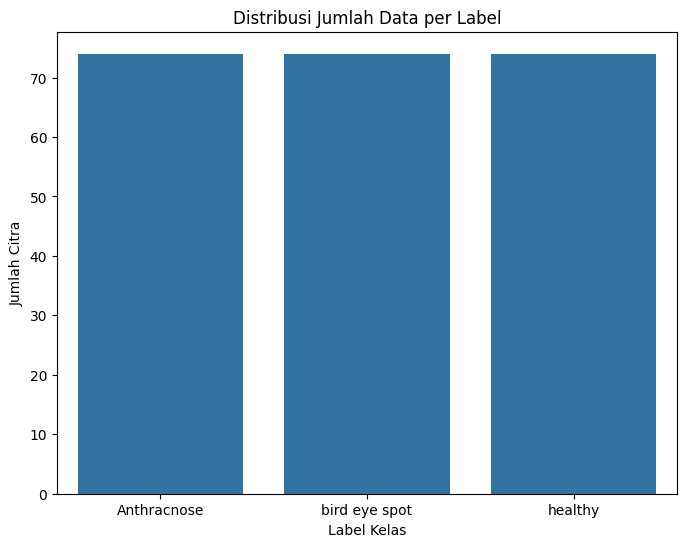

Total jumlah citra dalam dataset: 222
Total jumlah label dalam dataset: 222
Jumlah kelas unik: 3

Jumlah citra per kelas:
Anthracnose      74
bird eye spot    74
healthy          74
Name: count, dtype: int64


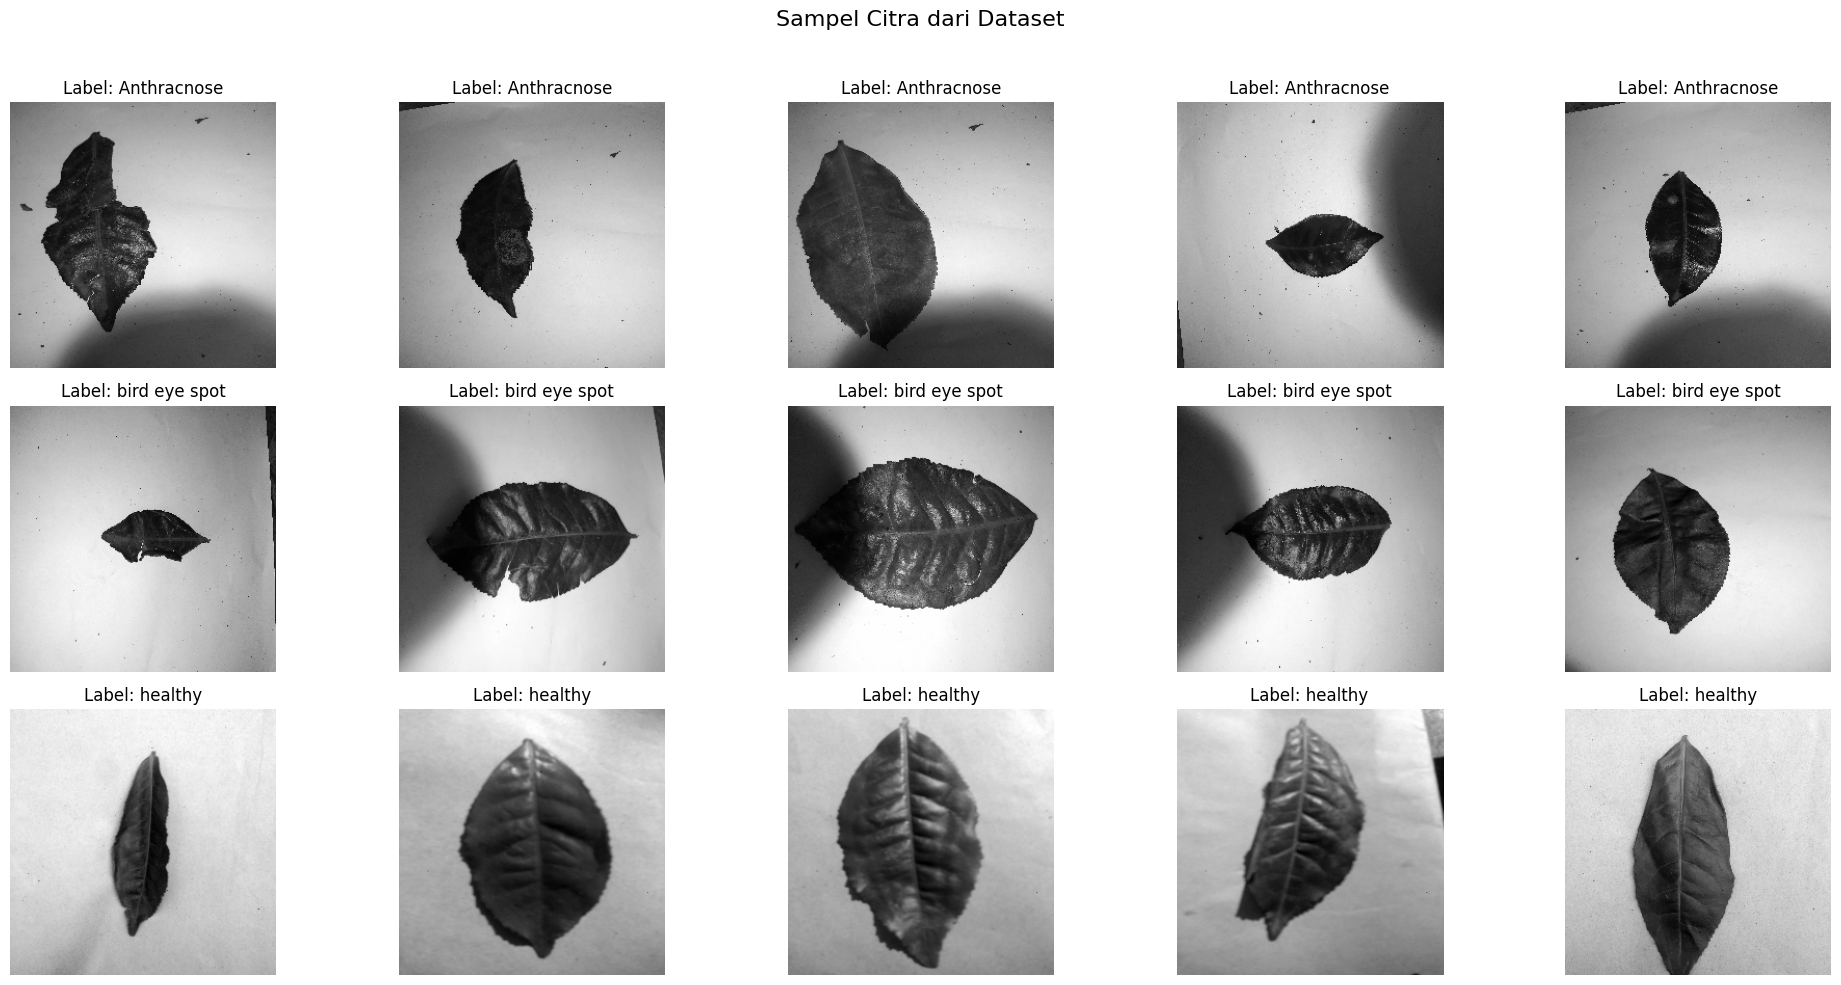

In [ ]:
# Mengubah list labels menjadi pandas Series untuk memudahkan penghitungan
label_series = pd.Series(labels)

# Menghitung jumlah kemunculan setiap label
label_counts = label_series.value_counts()

# Membuat diagram batang
plt.figure(figsize=(8, 6))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title('Distribusi Jumlah Data per Label')
plt.xlabel('Label Kelas')
plt.ylabel('Jumlah Citra')
plt.show()

# Menampilkan jumlah data dan label secara keseluruhan
print(f"Total jumlah citra dalam dataset: {len(data)}")
print(f"Total jumlah label dalam dataset: {len(labels)}")
print(f"Jumlah kelas unik: {len(label_counts)}")
print("\nJumlah citra per kelas:")
print(label_counts)

# Mendapatkan indeks untuk kelas 'Anthracnose', 'bird eye spot' dan 'healthy'
Anthracnose_indices = np.where(labels == 'Anthracnose')[0]
bird_eye_spot_indices = np.where(labels == 'bird eye spot')[0]
healthy_indices = np.where(labels == 'healthy')[0]

# Mengambil 5 sampel acak jika jumlahnya lebih dari 5, atau semua sampel jika kurang dari 5
num_samples_to_show = 5
if len(Anthracnose_indices) >= num_samples_to_show:
    sample_Anthracnose_indices = np.random.choice(Anthracnose_indices, num_samples_to_show, replace=False)
else:
    sample_Anthracnose_indices = Anthracnose_indices

if len(bird_eye_spot_indices) >= num_samples_to_show:
    sample_bird_eye_spot_indices = np.random.choice(bird_eye_spot_indices, num_samples_to_show, replace=False)
else:
    sample_bird_eye_spot_indices = bird_eye_spot_indices

if len(healthy_indices) >= num_samples_to_show:
    sample_healthy_indices = np.random.choice(healthy_indices, num_samples_to_show, replace=False)
else:
    sample_healthy_indices = healthy_indices

# Menggabungkan indeks sampel
sample_indices = np.concatenate((sample_Anthracnose_indices, sample_bird_eye_spot_indices, sample_healthy_indices))

# Ubah bagian for loop untuk plotting sampel
plt.figure(figsize=(20, 10))
plt.suptitle('Sampel Citra dari Dataset', fontsize=16)

# Gunakan 3 baris (sesuai jumlah kelas) dan 5 kolom (sesuai num_samples_to_show)
for i, index in enumerate(sample_indices):
    plt.subplot(3, num_samples_to_show, i + 1) 
    plt.imshow(data[index], cmap='gray') 
    plt.title(f"Label: {labels[index]}")
    plt.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Fungsi dibawah disusun untuk menyajikan representasi visual dari setiap kelas yang ada dalam dataset secara otomatis. Program mengidentifikasi semua kategori unik yang terdapat pada variabel labels, kemudian melakukan iterasi untuk memilih satu contoh citra dari tiap-tiap kelas tersebut. Jika suatu kelas memiliki jumlah data yang mencukupi, program akan menampilkan citra pada indeks ke-10 ke dalam sebuah tata letak grid yang rapi. Tujuannya adalah untuk memberikan gambaran visual yang cepat dan konsisten mengenai karakteristik citra dari masing-masing kategori, sehingga perbedaan visual antar kelas dapat diamati dengan lebih mudah.

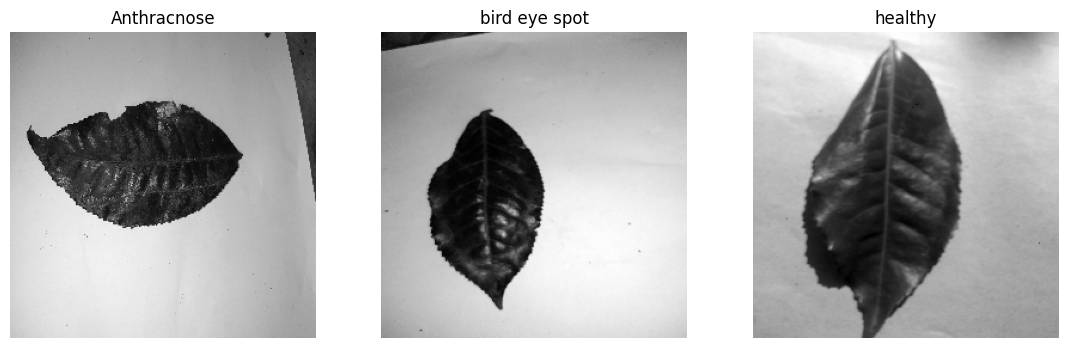

In [ ]:
class_names = np.unique(labels)

def show_sample_images(images, labels, class_names):
    plt.figure(figsize=(15, 10))
    for i, class_name in enumerate(class_names):
        class_images = images[labels == class_name]
        if len(class_images) > 10:
            plt.subplot(3, 4, i + 1)
            plt.imshow(class_images[10], cmap='gray')
            plt.title(class_name)
            plt.axis('off')
    plt.tight_layout()
    plt.show()

show_sample_images(data, labels, class_names)

In [6]:
def resize_image(image, new_width, new_height):
    old_height, old_width = image.shape[:2]
    resized_image = np.zeros((new_height, new_width), dtype=np.uint8)
    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)
            resized_image[i, j] = image[y, x]
    return resized_image

Fungsi resize_image diatas mengimplementasikan algoritma nearest neighbor interpolation secara manual untuk mengubah dimensi citra ke ukuran yang ditentukan tanpa menggunakan pustaka eksternal. Secara teknis, fungsi ini membuat sebuah array kosong dengan dimensi baru, kemudian melakukan iterasi piksel demi piksel untuk memetakan koordinat dari citra asli ke koordinat yang sesuai pada citra target dengan melakukan perhitungan rasio perbandingan ukuran. Pendekatan ini memastikan bahwa setiap piksel pada citra hasil merupakan hasil pengambilan nilai dari titik terdekat pada citra sumber, sehingga ukuran gambar dapat disesuaikan sesuai kebutuhan sistem.

Kode dibawah berfungsi untuk memverifikasi hasil dari fungsi resize_image yang telah dibuat sebelumnya melalui perbandingan visual. Program mengambil satu sampel citra dari dataset, menerapkan proses perubahan ukuran menjadi 128x128 piksel menggunakan fungsi tersebut, kemudian menyandingkan citra asli dengan citra hasil perubahan ukuran dalam satu tampilan visual. Langkah ini sangat krusial dalam laporan penelitian untuk menunjukkan secara objektif bahwa proses perubahan dimensi telah berhasil dilakukan dengan tetap mempertahankan kualitas visual yang diperlukan bagi tahap klasifikasi selanjutnya.

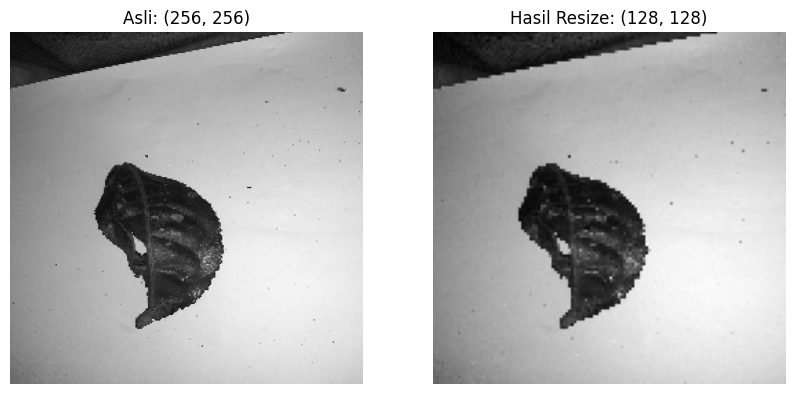

In [ ]:
gambar_asli = data[0]

lebar_baru = 128
tinggi_baru = 128
gambar_resize = resize_image(gambar_asli, lebar_baru, tinggi_baru)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(gambar_asli, cmap='gray')
plt.title(f"Asli: {gambar_asli.shape}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gambar_resize, cmap='gray')
plt.title(f"Hasil Resize: {gambar_resize.shape}")
plt.axis('off')

plt.show()

Kode dibawah bertujuan untuk memastikan keseragaman format warna pada seluruh dataset dengan melakukan proses konversi ke skala keabuan (grayscale) secara selektif. Program melakukan iterasi pada setiap citra dan memeriksa dimensinya, dimana jika citra masih memiliki tiga saluran warna (RGB/BGR), sistem akan mengubahnya menjadi satu saluran (grayscale), namun jika citra sudah berada dalam format dua dimensi, sistem akan membiarkannya tetap sebagaimana adanya. Setelah seluruh data dipastikan konsisten, hasil akhirnya dikonversi kembali menjadi larik (array) NumPy dan divalidasi dengan menampilkan sampel citra melalui fungsi show_sample_images untuk memastikan bahwa proses konversi warna berjalan dengan benar tanpa merusak informasi visual yang dibutuhkan.

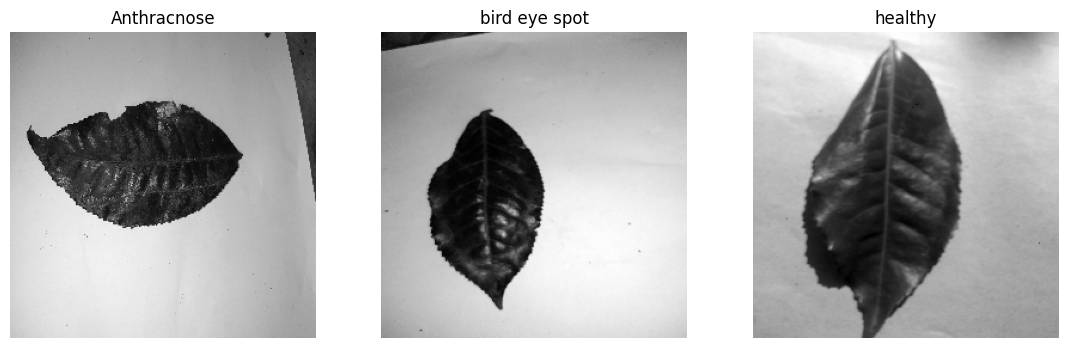

In [ ]:
img_grey = []
for img in data:
    # Cek dulu apakah gambar sudah grayscale (punya 2 dimensi/tidak punya channel warna)
    if len(img.shape) == 2:
        img_grey.append(img)
    else:
        # Jika belum (masih 3 channel), baru lakukan konversi
        gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        img_grey.append(gray)

img_grey = np.array(img_grey)

show_sample_images(img_grey, labels, class_names)

In [ ]:
def ekualisasi_histogram(citra):
    panjang, lebar = citra.shape

    # Hitung histogram
    histogram = np.zeros(256, dtype=int)
    for i in range(panjang):
        for j in range(lebar):
            nilai = citra[i, j]
            histogram[nilai] += 1

    # Hitung CDF
    cdf = np.zeros(256, dtype=int)
    for i in range(256):
        cdf[i] = np.sum(histogram[:i+1])

    # Normalisasi CDF
    cdf_min = cdf[cdf > 0].min() if np.any(cdf > 0) else 0
    cdf_norm = np.round((cdf - cdf_min) / (panjang * lebar - cdf_min) * 255).astype(int)

    # Petakan nilai baru
    hasil = np.zeros_like(citra, dtype=int)
    for i in range(panjang):
        for j in range(lebar):
            val = citra[i, j]
            hasil[i, j] = cdf_norm[val]

    return hasil.astype(np.uint8)

Fungsi ekualisasi_histogram diatas diimplementasikan untuk meningkatkan kontras citra secara otomatis dengan meratakan distribusi intensitas piksel. Proses ini diawali dengan menghitung frekuensi kemunculan setiap nilai keabuan, kemudian membangun fungsi distribusi kumulatif (Cumulative Distribution Function atau CDF) sebagai dasar normalisasi. Nilai piksel pada citra asli kemudian dipetakan kembali ke rentang nilai baru berdasarkan hasil normalisasi tersebut, sehingga intensitas warna pada citra terdistribusi lebih merata.

In [ ]:
def filter_citra(img, size, mode):
    # dimensi gambar
    height, width = img.shape
    # ukuran padding
    pad = size // 2
    # tambah padding tepi / add edge padding
    padded = np.pad(img, pad, mode='edge')
    # kanvas hasil
    canvas = np.zeros_like(img, dtype=np.uint8)
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total_sum = 0
                    for row in region:
                        for pixel in row:
                            total_sum += int(pixel)

                    canvas[i, j] = total_sum // area

        case 'median':
            # filter median
            for i in range(height):
                for j in range(width):
                    # area kernel
                    region = padded[i:i+size, j:j+size]
                    # rumus median manual
                    values = []
                    for row in region:
                        for val in row:
                            values.append(val)
                    # urutkan manual
                    n = len(values)
                    for a in range(n):
                        for b in range(0, n - a - 1):
                            if values[b] > values[b + 1]:
                                values[b], values[b + 1] = values[b + 1], values[b]
                    # ambil nilai tengah
                    mid = n // 2
                    if n % 2 == 0:
                        canvas[i, j] = (values[mid - 1] + values[mid]) // 2
                    else:
                        canvas[i, j] = values[mid]

        case 'modus':
            # filter modus
            for i in range(height):
                for j in range(width):
                    # area kernel
                    region = padded[i:i+size, j:j+size]
                    # ratakan array
                    values = region.ravel()
                    # hitung kemunculan
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    # cari nilai terbanyak
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    # simpan hasil
                    canvas[i, j] = mode_val

    return canvas

Fungsi filter_citra diatas dirancang untuk menerapkan teknik perbaikan citra melalui operasi spatial filtering berbasis kernel dengan ukuran yang dapat ditentukan. Sistem terlebih dahulu menambahkan padding pada tepi citra agar proses penyaringan dapat mencakup seluruh area gambar secara menyeluruh. Tergantung pada parameter mode yang dipilih, fungsi akan menjalankan salah satu dari tiga metode statistik: mean filter untuk meratakan intensitas (penghalusan), median filter untuk mereduksi derau (noise) dengan mengurutkan nilai piksel dalam kernel, atau modus filter untuk mengganti nilai piksel dengan nilai yang paling sering muncul di sekitarnya. Implementasi manual ini memungkinkan kontrol penuh terhadap bagaimana setiap piksel dihitung dan dimodifikasi untuk meningkatkan kualitas citra sebelum masuk ke tahap analisis fitur.

In [ ]:
def median_equal(img):
    # 1. resize
    img = cv.resize(img, (128, 128))
    
    # 2. median filter pakai fungsi filter_citra yg sudah ada
    img_median = filter_citra(img, size=3, mode='median')
    
    img_eq = ekualisasi_histogram(img_median)
       
    return img_eq

# apply ke semua data
dataMedianEqual = [median_equal(img) for img in data]

Fungsi median_equal di atas berperan sebagai alur kerja pra-pemrosesan yang menggabungkan dua teknik perbaikan citra utama. Pertama, citra diseragamkan ukurannya menjadi 128x128 piksel, kemudian melalui proses median filtering untuk mereduksi derau atau noise agar informasi tepi pada gambar lebih bersih. Langkah selanjutnya adalah menerapkan ekualisasi histogram untuk menyeimbangkan distribusi intensitas warna, sehingga kontras gambar menjadi lebih optimal dan fitur-fitur penting lebih menonjol. Secara keseluruhan, penerapan fungsi ini pada seluruh dataset melalui list comprehension menghasilkan kumpulan citra yang telah melalui tahap pembersihan dan peningkatan kualitas, sehingga lebih siap untuk diekstraksi fiturnya pada tahapan klasifikasi selanjutnya.

Fungsi tampilkan_perbandingan dibawah disusun sebagai alat verifikasi visual untuk mengevaluasi dampak dari tahapan pra-pemrosesan yang telah dilakukan terhadap citra asli. Dengan menggunakan indeks sebagai parameter input, fungsi ini memanggil citra sumber dan citra hasil proses (dataMedianEqual), lalu menyajikannya secara berdampingan dalam sebuah visualisasi perbandingan. Langkah ini krusial dalam laporan penelitian untuk mendemonstrasikan secara nyata perbedaan kualitas antara citra mentah dengan citra yang telah dibersihkan dari derau serta ditingkatkan kontrasnya, sehingga efektivitas metode yang diterapkan dapat dinilai secara objektif.

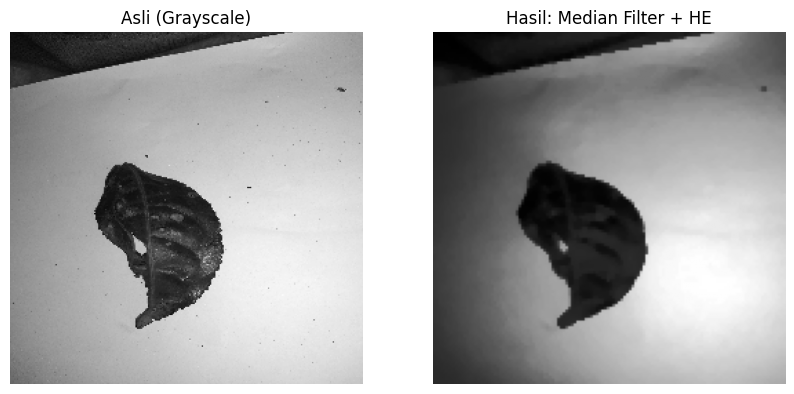

In [12]:
def tampilkan_perbandingan(idx):
    img_asli = data[idx]
    img_hasil = dataMedianEqual[idx]
    
    plt.figure(figsize=(10, 5))
    
    # Menampilkan gambar asli
    plt.subplot(1, 2, 1)
    plt.imshow(img_asli, cmap='gray')
    plt.title("Asli (Grayscale)")
    plt.axis('off')
    
    # Menampilkan gambar hasil Median + Equalization
    plt.subplot(1, 2, 2)
    plt.imshow(img_hasil, cmap='gray')
    plt.title("Hasil: Median Filter + HE")
    plt.axis('off')
    
    plt.show()

# Panggil fungsi untuk melihat perbandingan (contoh untuk gambar ke-0)
tampilkan_perbandingan(0)

In [13]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")
    
    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

Fungsi glcm diatas dibuat untuk mengekstraksi fitur tekstur pada citra menggunakan metode Gray-Level Co-occurrence Matrix (GLCM). Fungsi menerima input berupa citra dan nilai derajat sudut (0, 45, 90, atau 135) yang kemudian dikonversi ke dalam satuan radian sesuai kebutuhan pustaka skimage. Setelah sudut ditentukan, fungsi melakukan perhitungan matriks ko-okurensi dengan jarak satu piksel (distance=1) dan parameter symmetric=True untuk memastikan bahwa keterhubungan antar piksel dihitung tanpa memandang arah orientasi. Hasil akhirnya adalah sebuah matriks yang merepresentasikan seberapa sering pasangan nilai intensitas piksel tertentu muncul bersamaan pada orientasi yang telah ditentukan, yang nantinya akan digunakan sebagai fitur utama dalam proses klasifikasi gambar.

In [14]:
def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

Fungsi-fungsi di atas berfungsi untuk melakukan ekstraksi fitur statistik dari matriks GLCM yang telah dihasilkan sebelumnya. Setiap fungsi memanfaatkan pustaka skimage (khususnya graycoprops) untuk menghitung nilai deskriptif tekstur, seperti correlation untuk mengukur ketergantungan antar piksel, dissimilarity dan contrast untuk mengukur variasi intensitas, serta homogeneity untuk mengukur kemiripan tekstur. Selain itu, terdapat perhitungan ASM (Angular Second Moment) dan energy untuk mengukur keteraturan tekstur, serta entropy yang digunakan untuk mengukur kerumitan atau keacakan distribusi piksel dalam citra. Kumpulan nilai statistik ini berperan sebagai representasi fitur numerik yang nantinya akan digunakan sebagai input utama dalam melatih model klasifikasi.

In [15]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Bagian kode diatas melakukan ekstraksi fitur tekstur secara komprehensif dengan memproses seluruh dataset pada empat arah orientasi yang berbeda, yaitu 0, 45, 90, dan 135 derajat. Melalui iterasi pada setiap citra dalam dataPreprocessed, program memanggil fungsi glcm untuk menghasilkan matriks ko-okurensi untuk masing-masing sudut tersebut, yang kemudian disimpan ke dalam daftar (list) terpisah berdasarkan orientasinya. Proses ini sangat krusial dalam tahapan ekstraksi fitur karena memungkinkan sistem untuk menangkap karakteristik tekstur dari berbagai arah, sehingga representasi data yang dihasilkan menjadi jauh lebih kaya dan akurat dalam mendeskripsikan variasi visual pada setiap sampel citra sebelum nantinya diproses lebih lanjut oleh model klasifikasi.

In [16]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

Bagian kode tersebut berfungsi untuk menginisialisasi wadah penampung (list) yang akan digunakan untuk menyimpan hasil perhitungan nilai statistik tekstur dari setiap citra. Untuk masing-masing dari tujuh jenis fitur GLCM, yaitu contrast, dissimilarity, homogeneity, entropy, ASM, energy, dan correlation, disediakan empat variabel penampung yang mewakili empat arah orientasi (0, 45, 90, dan 135 derajat). Dengan struktur ini, nilai numerik hasil ekstraksi dari setiap citra akan dikelompokkan secara sistematis berdasarkan jenis fitur dan sudut orientasinya. Inisialisasi ini merupakan langkah persiapan sebelum data tersebut nantinya disusun ke dalam tabel yang terorganisasi, yang berfungsi sebagai set fitur final untuk proses pelatihan model klasifikasi.

In [17]:
for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

Kode diatas berfungsi untuk menghitung nilai fitur statistik correlation dari matriks GLCM yang telah dibuat sebelumnya pada setiap arah orientasi. Melalui perulangan (looping) pada seluruh dataset, program mengambil data GLCM dari setiap sudut (0°, 45°, 90°, dan 135°), menghitung nilai korelasinya menggunakan fungsi correlation, lalu menyimpannya ke dalam variabel daftar (list) yang telah dipersiapkan sebelumnya. Hasil dari proses ini adalah deretan nilai numerik yang merepresentasikan hubungan ketergantungan antar piksel dalam citra, yang menjadi data masukan penting untuk menunjukkan karakteristik tekstur objek.

In [18]:
for i in range(len(data)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

Kode diatas berfungsi untuk mengekstrak nilai statistik contrast dari matriks GLCM untuk setiap citra dalam dataset pada empat arah orientasi yang berbeda. Melalui proses iterasi, program memanggil fungsi contrast guna mengukur perbedaan intensitas piksel yang signifikan dalam citra pada sudut 0°, 45°, 90°, dan 135°, kemudian menyimpan hasil perhitungan tersebut ke dalam daftar (list) yang sesuai. Nilai contrast ini sangat penting untuk menangkap variasi tekstur, di mana nilai yang lebih tinggi menunjukkan adanya perbedaan intensitas yang tajam antar piksel yang bertetangga, sehingga memberikan informasi krusial mengenai detail permukaan objek.

In [19]:
for i in range(len(data)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

Kode diatas melanjutkan proses ekstraksi fitur tekstur dengan menghitung nilai dissimilarity (ketidaksamaan) dari matriks GLCM untuk setiap citra dalam dataset. Melalui perulangan yang sama, program mengukur tingkat perbedaan intensitas piksel yang bertetangga pada empat sudut orientasi (0°, 45°, 90°, dan 135°), lalu menyimpannya ke dalam daftar yang relevan. Nilai dissimilarity ini memberikan informasi penting mengenai seberapa bervariasi atau heterogen tekstur pada permukaan citra; semakin tinggi nilai yang diperoleh, semakin besar perbedaan intensitas rata-rata antar piksel tetangganya. Data ini melengkapi profil tekstur setiap citra yang nantinya akan digunakan untuk membedakan karakteristik antar kelas dalam model klasifikasi.

In [20]:
for i in range(len(data)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

Kode diatas melanjutkan ekstraksi fitur statistik dengan menghitung nilai homogeneity (homogenitas) dari matriks GLCM untuk setiap citra pada empat arah orientasi (0°, 45°, 90°, dan 135°). Fungsi homogenity mengukur seberapa dekat distribusi elemen dalam matriks GLCM dengan diagonal utama, yang secara praktis mencerminkan tingkat kemiripan atau keteraturan tekstur pada citra. Nilai yang tinggi mengindikasikan bahwa citra memiliki tekstur yang sangat seragam atau memiliki perubahan intensitas yang halus, sedangkan nilai rendah menunjukkan adanya perubahan tekstur yang lebih kompleks atau kasar.

In [21]:
for i in range(len(data)):  
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

Kode diatas mengekstrak fitur entropy dari matriks GLCM untuk setiap citra pada dataset di empat arah orientasi (0°, 45°, 90°, dan 135°). Dalam konteks analisis tekstur, entropy mengukur tingkat kompleksitas, kekacauan, atau ketidakteraturan distribusi intensitas piksel dalam citra. Nilai entropy yang tinggi menunjukkan bahwa tekstur citra sangat acak dan kompleks, sedangkan nilai yang rendah menandakan bahwa citra tersebut memiliki tekstur yang lebih terstruktur atau seragam.

In [22]:
for i in range(len(data)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

Kode diatas melanjutkan proses ekstraksi fitur dengan menghitung nilai ASM (Angular Second Moment) dari matriks GLCM untuk setiap citra dalam dataset pada empat arah orientasi (0°, 45°, 90°, dan 135°). Nilai ASM, yang juga dikenal sebagai uniformity atau keseragaman, mengukur seberapa besar kemiripan atau keteraturan piksel dalam citra. Nilai ASM yang tinggi menunjukkan bahwa citra memiliki distribusi intensitas yang seragam atau memiliki pola tekstur yang sangat teratur, sedangkan nilai yang rendah menunjukkan variasi tekstur yang lebih kompleks.

In [23]:
for i in range(len(data)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

Kode diatas menyelesaikan langkah ekstraksi fitur statistik tekstur dengan menghitung nilai Energy dari matriks GLCM untuk setiap citra dalam dataset pada empat arah orientasi (0°, 45°, 90°, dan 135°). Dalam analisis GLCM, nilai Energy (sering disebut sebagai Uniformity) merupakan akar kuadrat dari Angular Second Moment (ASM) dan berfungsi untuk mengukur seberapa besar konsentrasi distribusi intensitas piksel dalam citra. Nilai Energy yang tinggi menunjukkan bahwa citra memiliki pola tekstur yang sangat teratur dan seragam, sedangkan nilai yang rendah menandakan distribusi intensitas yang lebih menyebar atau kompleks.

Kode dibawah berfungsi sebagai tahap konsolidasi fitur yang krusial dalam alur kerja sistem Computer Vision. Dengan mengelompokkan berbagai list fitur statistik, seperti contrast, homogeneity, dissimilarity, entropy, ASM, energy, dan correlation ke dalam sebuah dictionary bernama dataTable, dilakukan pemetaan data terstruktur dari bentuk matriks visual yang kompleks menjadi format tabel numerik standar. Penggunaan pd.DataFrame untuk mengonversi dictionary tersebut adalah langkah yang tepat karena pustaka pandas menyediakan struktur data yang efisien, mudah dikelola, dan telah dioptimalkan untuk operasi pemrosesan data skala besar.

Penyimpanan data ke dalam file .csv melalui to_csv bertindak sebagai checkpoint data yang menjaga persistensi hasil ekstraksi, sehingga proses komputasi fitur yang intensif tidak perlu diulang setiap kali akan dilakukan pelatihan model. Ketika data tersebut dibaca kembali dengan pd.read_csv, variabel hasilEkstrak yang terbentuk menjadi dataset siap pakai yang secara konsisten menyelaraskan baris (sampel citra) dengan kolom (fitur statistik pada empat sudut orientasi). Hal ini merupakan fondasi mutlak agar algoritma pembelajaran mesin, seperti Support Vector Machine atau Random Forest, dapat mengenali pola tekstur dengan akurat dan efisien.

In [24]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_1.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_1.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,IMG_20220503_143242.jpg,Anthracnose,114.429134,227.030876,159.648191,214.832662,0.463520,0.401158,0.438623,0.398753,...,0.001308,0.001176,0.038104,0.034425,0.036168,0.034297,0.980309,0.960690,0.972316,0.962796
1,IMG_20220503_143328.jpg,Anthracnose,107.758305,168.043710,109.085630,173.686713,0.454380,0.426608,0.488004,0.415010,...,0.001600,0.001330,0.038220,0.036483,0.039996,0.036475,0.976366,0.963269,0.976060,0.962040
2,IMG_20220503_143336.jpg,Anthracnose,174.339998,210.625457,115.019439,235.266911,0.458989,0.387157,0.434333,0.409386,...,0.001164,0.001069,0.035710,0.032124,0.034117,0.032698,0.974418,0.969263,0.983137,0.965666
3,IMG_20220503_143344.jpg,Anthracnose,140.601132,187.363321,90.833231,185.401327,0.489240,0.417212,0.471439,0.444965,...,0.001545,0.001407,0.040841,0.036725,0.039307,0.037514,0.971566,0.961999,0.981517,0.962392
4,IMG_20220503_143352.jpg,Anthracnose,157.701218,269.664517,173.940822,265.270879,0.462449,0.391117,0.433752,0.406487,...,0.001320,0.001199,0.038463,0.034046,0.036333,0.034622,0.976079,0.958822,0.973351,0.959488
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,UNADJUSTEDNONRAW_thumb_24b.jpg,healthy,67.894870,78.052204,21.820189,70.359725,0.321390,0.306126,0.349316,0.309010,...,0.001780,0.001596,0.040809,0.040006,0.042185,0.039948,0.977953,0.974765,0.992909,0.977252
218,UNADJUSTEDNONRAW_thumb_24c.jpg,healthy,33.459646,53.042284,28.079601,48.343109,0.329106,0.298217,0.345565,0.314242,...,0.001317,0.001175,0.034996,0.033533,0.036290,0.034273,0.992175,0.987628,0.993420,0.988724
219,UNADJUSTEDNONRAW_thumb_24d.jpg,healthy,34.412648,52.491289,27.663755,48.230020,0.313068,0.288044,0.334404,0.301300,...,0.001259,0.001125,0.034025,0.032806,0.035479,0.033546,0.991927,0.987713,0.993495,0.988711
220,UNADJUSTEDNONRAW_thumb_24e.jpg,healthy,70.348056,82.349743,29.681287,86.616777,0.305637,0.294843,0.340470,0.276414,...,0.001294,0.001087,0.034229,0.033319,0.035977,0.032970,0.986408,0.984152,0.994262,0.983331


Kode dibawah mengimplementasikan teknik seleksi fitur berbasis korelasi untuk mengatasi multikolinearitas dengan cara mengeliminasi fitur-fitur yang memiliki redundansi informasi tinggi, yakni fitur yang memiliki nilai korelasi di atas ambang batas (threshold) 0,95. Melalui proses iterasi pada matriks korelasi, variabel yang dianggap tumpang tindih dihapus dari dataset, sehingga menyisakan fitur-fitur unik yang lebih efisien dan informatif untuk proses pembelajaran mesin. Langkah ini tidak hanya berfungsi mereduksi dimensi data untuk mempercepat waktu komputasi, tetapi juga meningkatkan stabilitas model serta mencegah overfitting dengan memastikan bahwa setiap fitur yang digunakan memberikan kontribusi yang berbeda. Visualisasi heatmap yang dihasilkan pada akhir proses berperan sebagai verifikasi statistik untuk memastikan bahwa subset fitur akhir (x_new) kini lebih bersih dari korelasi ekstrem, sehingga siap digunakan sebagai input yang optimal bagi algoritma klasifikasi.

<Axes: >

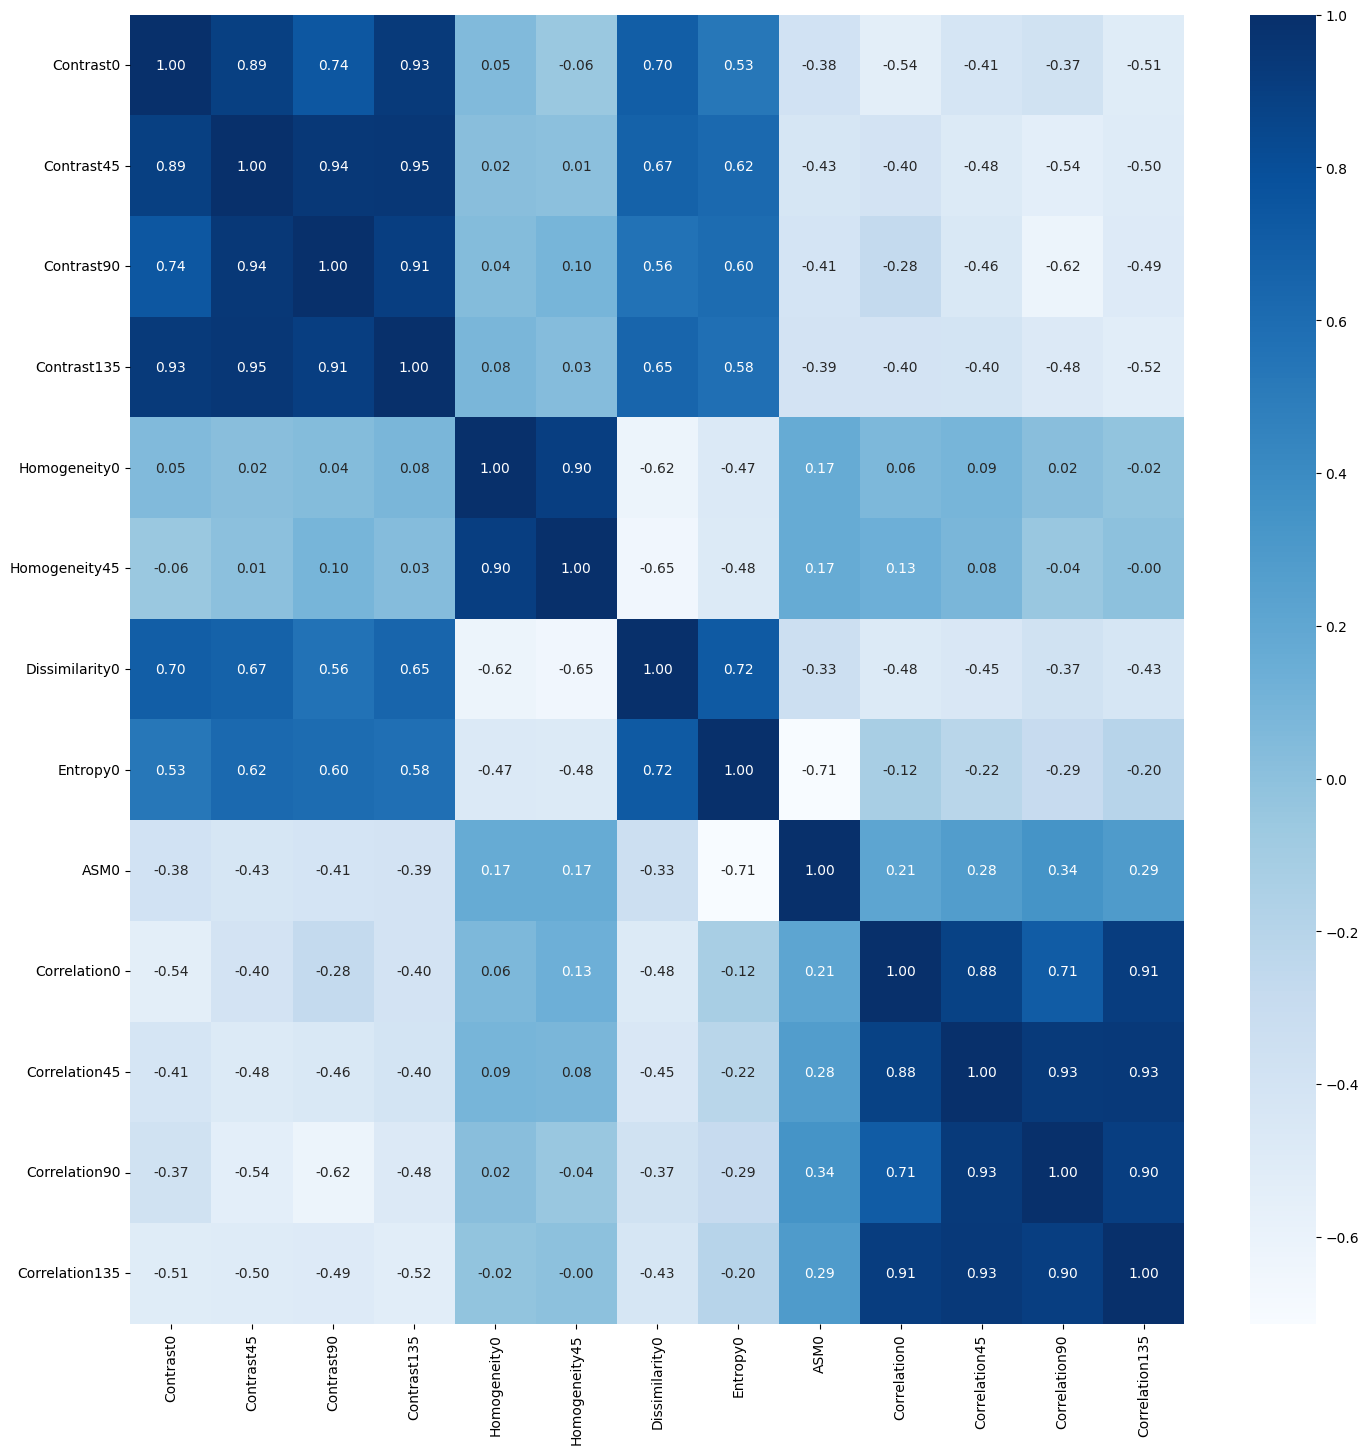

In [25]:
# Menghitung korelasi
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")

In [26]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(177, 13)
(45, 13)


Proses diatas bertujuan membagi data menjadi dua bagian: training set (80%) untuk melatih model dan testing set (20%) untuk menguji performa pada data baru. Penggunaan random_state=42 memastikan pembagian data selalu konsisten setiap kali kode dijalankan, sehingga eksperimen dapat direplikasi.  Langkah ini sangat penting untuk mendeteksi overfitting dan memastikan model mampu melakukan generalisasi dengan baik pada data yang belum pernah dilihat sebelumnya.

In [27]:
# normalisasi mean std
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

Tahap diatas merupakan normalisasi z-score atau standarisasi, yang bertujuan untuk menyamakan skala seluruh fitur agar memiliki nilai rata-rata (mean) sebesar 0 dan standar deviasi sebesar 1. Hal ini sangat penting karena fitur tekstur seperti Contrast dan Entropy memiliki rentang nilai yang sangat berbeda, sehingga tanpa normalisasi, model klasifikasi akan cenderung bias dan hanya berfokus pada fitur dengan nilai numerik terbesar. Penggunaan statistik dari X_train untuk menormalisasi X_test dilakukan guna menghindari kebocoran data (data leakage), sehingga model tetap objektif saat dievaluasi menggunakan data pengujian yang belum pernah diproses sebelumnya.

In [28]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

Fungsi diatas digunakan untuk mengevaluasi performa model melalui metrik classification report (akurasi, precision, recall, f1-score), matriks kebingungan (confusion matrix), dan skor akurasi keseluruhan. Selanjutnya, didefinisikan tiga algoritma klasifikasi yaitu Random Forest (untuk pemrosesan data berbasis pohon), Support Vector Machine (untuk klasifikasi non-linear dengan kernel RBF), dan K-Nearest Neighbors (untuk klasifikasi berbasis kedekatan jarak).

In [29]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
               precision    recall  f1-score   support

  Anthracnose       0.97      0.92      0.94        61
bird eye spot       0.91      0.96      0.94        54
      healthy       1.00      1.00      1.00        62

     accuracy                           0.96       177
    macro avg       0.96      0.96      0.96       177
 weighted avg       0.96      0.96      0.96       177

[[56  5  0]
 [ 2 52  0]
 [ 0  0 62]]
Accuracy: 0.96045197740113

------Testing Set------
               precision    recall  f1-score   support

  Anthracnose       0.50      0.69      0.58        13
bird eye spot       0.79      0.55      0.65        20
      healthy       0.92      1.00      0.96        12

     accuracy                           0.71        45
    macro avg       0.74      0.75      0.73        45
 weighted avg       0.74      0.71      0.71        45

[[ 9  3  1]
 [ 9 11  0]
 [ 0  0 12]]
Accuracy: 0.7111111111111111


Kode diatas merupakan proses pelatihan (fitting) model Random Forest terhadap data latih untuk membangun pola klasifikasi, yang diikuti dengan evaluasi performa pada training set dan testing set secara terpisah. Evaluasi pada training set berfungsi untuk melihat seberapa baik model mempelajari data internal, sedangkan evaluasi pada testing set bertujuan untuk mengukur kemampuan generalisasi model terhadap data baru yang belum pernah ditemui sebelumnya. Dengan menggunakan fungsi generateClassificationReport, laporan performa yang mencakup metrik presisi, recall, skor F1, serta matriks kebingungan akan ditampilkan secara otomatis untuk memberikan gambaran komprehensif mengenai tingkat akurasi klasifikasi yang dicapai.

In [30]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
               precision    recall  f1-score   support

  Anthracnose       0.68      0.87      0.76        61
bird eye spot       0.81      0.54      0.64        54
      healthy       0.98      1.00      0.99        62

     accuracy                           0.81       177
    macro avg       0.82      0.80      0.80       177
 weighted avg       0.82      0.81      0.81       177

[[53  7  1]
 [25 29  0]
 [ 0  0 62]]
Accuracy: 0.8135593220338984

------Testing Set------
               precision    recall  f1-score   support

  Anthracnose       0.48      0.85      0.61        13
bird eye spot       0.89      0.40      0.55        20
      healthy       0.92      1.00      0.96        12

     accuracy                           0.69        45
    macro avg       0.76      0.75      0.71        45
 weighted avg       0.78      0.69      0.68        45

[[11  1  1]
 [12  8  0]
 [ 0  0 12]]
Accuracy: 0.6888888888888889


Kode diatas merupakan proses pelatihan model Support Vector Machine (SVM) dengan kernel RBF yang bertujuan menemukan hyperplane optimal untuk memisahkan kelas-kelas data dalam ruang fitur multidimensi. Setelah model dilatih menggunakan data latih, dilakukan evaluasi performa pada training set untuk mendeteksi potensi overfitting, serta pada testing set untuk mengukur kemampuan generalisasi model terhadap data baru yang belum pernah dilihat sebelumnya.  Perbandingan performa antara data latih dan data uji melalui classification report serta confusion matrix ini menjadi tolak ukur penting dalam menentukan efektivitas SVM dalam mengenali pola tekstur spesifik dibandingkan dengan model lain yang telah diuji sebelumnya.

In [31]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
               precision    recall  f1-score   support

  Anthracnose       0.77      0.87      0.82        61
bird eye spot       0.83      0.70      0.76        54
      healthy       0.98      0.98      0.98        62

     accuracy                           0.86       177
    macro avg       0.86      0.85      0.85       177
 weighted avg       0.86      0.86      0.86       177

[[53  7  1]
 [16 38  0]
 [ 0  1 61]]
Accuracy: 0.8587570621468926

------Testing Set------
               precision    recall  f1-score   support

  Anthracnose       0.50      0.69      0.58        13
bird eye spot       0.79      0.55      0.65        20
      healthy       0.92      1.00      0.96        12

     accuracy                           0.71        45
    macro avg       0.74      0.75      0.73        45
 weighted avg       0.74      0.71      0.71        45

[[ 9  3  1]
 [ 9 11  0]
 [ 0  0 12]]
Accuracy: 0.7111111111111111


Kode diatas melatih model K-Nearest Neighbors (KNN) yang bekerja berdasarkan prinsip kedekatan jarak antar titik data dalam ruang fitur untuk menentukan kelas sampel uji. Setelah model dilatih, evaluasi dilakukan pada training set untuk melihat konsistensi internal, serta pada testing set untuk mengukur akurasi generalisasi model terhadap data baru berdasarkan neighbors terdekat.  Perbandingan metrik performa yang dihasilkan dari ketiga model (Random Forest, SVM, dan KNN) ini menjadi penentu utama dalam memilih algoritma terbaik untuk klasifikasi tekstur pada dataset tersebut.

Fungsi dibawah digunakan untuk memvisualisasikan Confusion Matrix dari ketiga model klasifikasi, yang memberikan representasi grafis mengenai jumlah prediksi benar (True Positives/Negatives) dan kesalahan klasifikasi (False Positives/Negatives) pada data uji. Dengan menggunakan pemetaan warna Blues pada heatmap, perbedaan distribusi prediksi antar kelas menjadi jauh lebih intuitif dan mudah diinterpretasi dibandingkan hanya melihat angka dalam bentuk tabel.  Visualisasi ini sangat krusial dalam laporan untuk mengidentifikasi apakah model memiliki kecenderungan salah klasifikasi pada kelas tertentu, sehingga performa setiap algoritma dapat dibandingkan secara visual untuk menentukan model dengan akurasi dan presisi paling optimal.

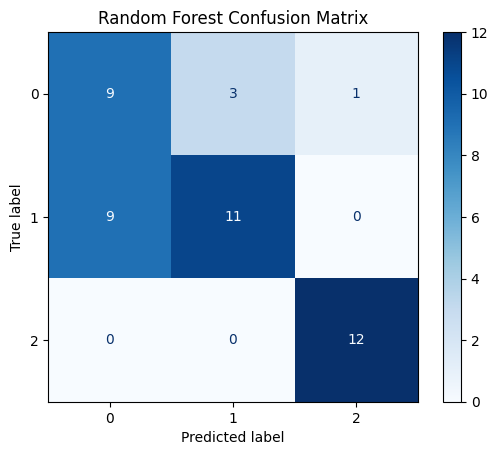

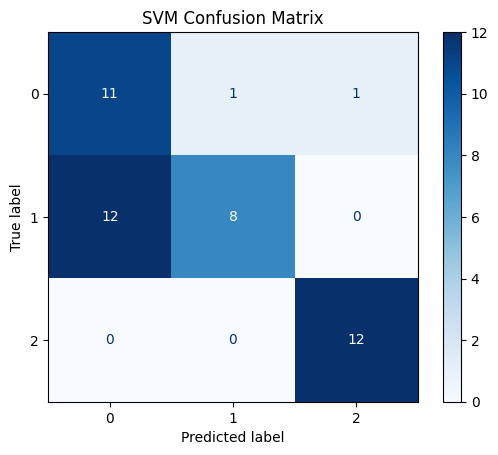

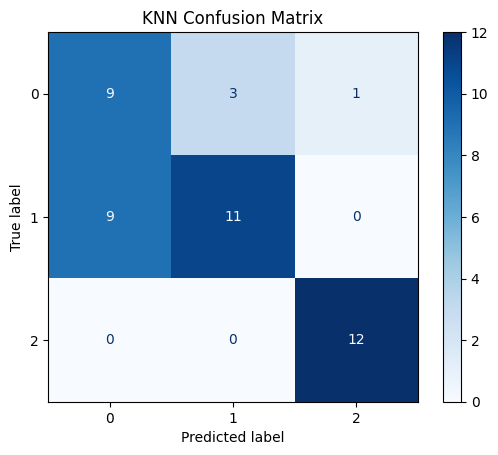

In [32]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")